# PII Detection Dataset Analysis

This notebook provides exploratory data analysis of the combined PII detection dataset used for training our DeBERTaV3 + DoRA model.

**Dataset:** [Ari-S-123/pii-detection-english-consolidated](https://huggingface.co/datasets/Ari-S-123/pii-detection-english-consolidated)

**Contents:**
1. Dataset Overview & Loading
2. Data Source Comparison (ai4privacy vs Synthetic)
3. Label Distribution Analysis
4. Synthetic Data Deep Dive
5. Text Statistics
6. Model Comparison Results

## 1. Dataset Overview & Loading

In [1]:
# Install dependencies if needed
%pip install datasets pandas matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
COLORS = {
    'primary': '#3b82f6',
    'secondary': '#10b981',
    'accent': '#f59e0b',
    'danger': '#ef4444',
    'purple': '#8b5cf6'
}

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load dataset from HuggingFace
DATASET_ID = "Ari-S-123/pii-detection-english-consolidated"

print(f"Loading dataset: {DATASET_ID}")
dataset = load_dataset(DATASET_ID)

print(f"\n{'='*60}")
print("DATASET OVERVIEW")
print(f"{'='*60}")
print(f"\nSplits available: {list(dataset.keys())}")
print(f"\nTrain samples: {len(dataset['train']):,}")
print(f"Test samples:  {len(dataset['test']):,}")
print(f"Total samples: {len(dataset['train']) + len(dataset['test']):,}")
print(f"\nColumns: {dataset['train'].column_names}")

Loading dataset: Ari-S-123/pii-detection-english-consolidated


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.93M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/125327 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/31361 [00:00<?, ? examples/s]


DATASET OVERVIEW

Splits available: ['train', 'test']

Train samples: 125,327
Test samples:  31,361
Total samples: 156,688

Columns: ['source_text', 'privacy_mask', 'feature_dimension', 'seed_pii_type', 'seed_pii_value', 'seed_pii_locale', 'scenario', 'type_variant', 'generation_id', 'data_source', 'language', 'region', 'script']


In [4]:
# Convert to pandas for easier analysis
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

# Combine for overall analysis
train_df['split'] = 'train'
test_df['split'] = 'test'
full_df = pd.concat([train_df, test_df], ignore_index=True)

print("Sample record:")
print("-" * 60)
sample = full_df.iloc[0]
print(f"Source: {sample['data_source']}")
print(f"Text: {sample['source_text'][:100]}...")
mask = sample['privacy_mask']
if hasattr(mask, 'tolist'):
    mask = mask.tolist()
print(f"Entities: {mask[:2]}..." if len(mask) > 2 else f"Entities: {mask}")

Sample record:
------------------------------------------------------------
Source: ai4privacy
Text: To-do list for 4th August 1942: meet with Brandy Haroon at 10:17 to discuss the volunteer service re...
Entities: [{'end': 30, 'label': 'DATE', 'label_index': 1, 'start': 15, 'value': '4th August 1942'}, {'end': 48, 'label': 'FIRSTNAME', 'label_index': 1, 'start': 42, 'value': 'Brandy'}]...


## 2. Data Source Comparison

Our dataset combines two sources:
- **ai4privacy**: English subset of the open-pii-masking-500k dataset
- **synthetic**: Generated samples targeting NER failure modes (Singh & Narayanan, 2025)

In [5]:
# Data source breakdown
source_counts = full_df['data_source'].value_counts()

print("Data Source Distribution")
print("=" * 40)
for source, count in source_counts.items():
    pct = count / len(full_df) * 100
    print(f"{source:15} {count:>8,} ({pct:>5.1f}%)")

# By split
print("\nBreakdown by Split")
print("=" * 40)
source_by_split = full_df.groupby(['split', 'data_source']).size().unstack(fill_value=0)
print(source_by_split)

Data Source Distribution
ai4privacy       150,686 ( 96.2%)
synthetic          6,002 (  3.8%)

Breakdown by Split
data_source  ai4privacy  synthetic
split                             
test              30160       1201
train            120526       4801


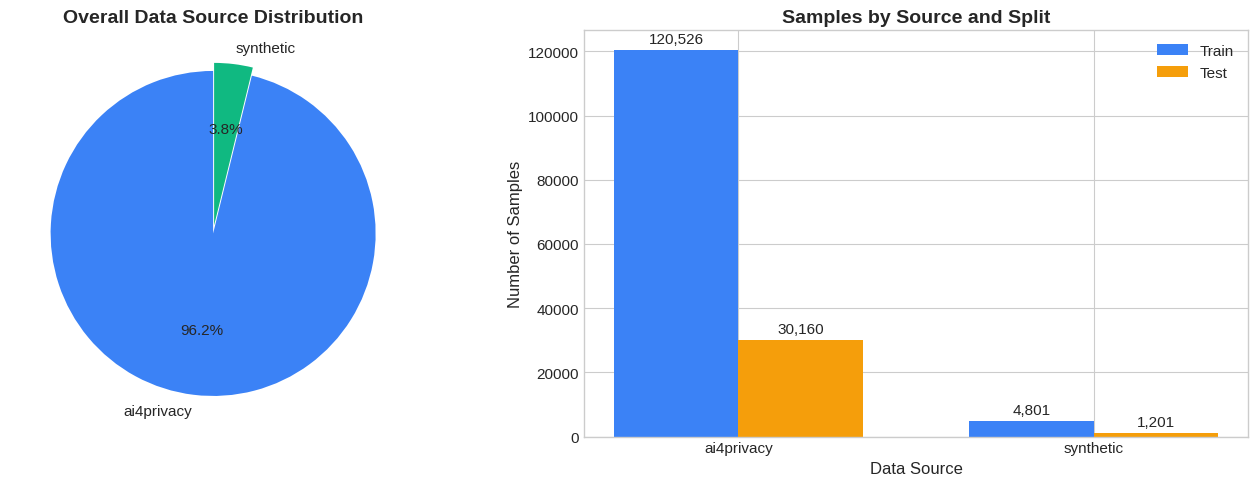

In [6]:
# Visualize data source distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - overall distribution
colors = [COLORS['primary'], COLORS['secondary']]
wedges, texts, autotexts = axes[0].pie(
    source_counts.values,
    labels=source_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=(0, 0.05),
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('Overall Data Source Distribution', fontweight='bold')

# Bar chart - by split
x = np.arange(2)
width = 0.35

train_counts = [source_by_split.loc['train', 'ai4privacy'], source_by_split.loc['train', 'synthetic']]
test_counts = [source_by_split.loc['test', 'ai4privacy'], source_by_split.loc['test', 'synthetic']]

bars1 = axes[1].bar(x - width/2, train_counts, width, label='Train', color=COLORS['primary'])
bars2 = axes[1].bar(x + width/2, test_counts, width, label='Test', color=COLORS['accent'])

axes[1].set_xlabel('Data Source')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Samples by Source and Split', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['ai4privacy', 'synthetic'])
axes[1].legend()
axes[1].bar_label(bars1, fmt='{:,.0f}', padding=3)
axes[1].bar_label(bars2, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.savefig('fig_data_sources.png', dpi=150, bbox_inches='tight')
plt.show()

## Note: We did not have the time or money to generate and validate more than 10,836 synthetic data samples. (6,002 of which were validated by GPT 5.1)

## 3. Label Distribution Analysis

The dataset contains 505 unique entity labels after consolidation. Labels were consolidated from 450+ variants (e.g., `PHONE`, `PHONE_NUMBER`, `TELEPHONENUM` → unified labels).

In [7]:
# Extract all labels from privacy_mask
def extract_labels(df):
    """Extract all entity labels from the privacy_mask column."""
    labels = []
    for mask_list in df['privacy_mask']:
        # Convert numpy array to list if needed
        if hasattr(mask_list, 'tolist'):
            mask_list = mask_list.tolist()
        # Now safely check length
        if mask_list is not None and len(mask_list) > 0:
            for entity in mask_list:
                if isinstance(entity, dict) and 'label' in entity:
                    labels.append(entity['label'])
    return labels

all_labels = extract_labels(full_df)
label_counts = Counter(all_labels)

print(f"Total entity annotations: {len(all_labels):,}")
print(f"Unique labels: {len(label_counts)}")
print(f"\nTop 20 Most Frequent Labels")
print("=" * 50)
for i, (label, count) in enumerate(label_counts.most_common(20), 1):
    pct = count / len(all_labels) * 100
    print(f"{i:>3}. {label:<30} {count:>8,} ({pct:>5.2f}%)")

Total entity annotations: 408,872
Unique labels: 252

Top 20 Most Frequent Labels
  1. FIRSTNAME                       124,059 (30.34%)
  2. LASTNAME                         46,637 (11.41%)
  3. PHONENUMBER                      27,749 ( 6.79%)
  4. CITY                             25,718 ( 6.29%)
  5. TIME                             25,318 ( 6.19%)
  6. DATE                             22,432 ( 5.49%)
  7. STREET                           20,061 ( 4.91%)
  8. EMAIL                            18,956 ( 4.64%)
  9. TITLE                            17,048 ( 4.17%)
 10. BUILDINGNUMBER                   15,607 ( 3.82%)
 11. IDCARDNUM                        14,270 ( 3.49%)
 12. AGE                               8,461 ( 2.07%)
 13. ZIPCODE                           6,970 ( 1.70%)
 14. PASSPORTNUM                       6,097 ( 1.49%)
 15. TAXNUM                            4,134 ( 1.01%)
 16. SSN                               3,745 ( 0.92%)
 17. SEX                               3,718 ( 0.91%)


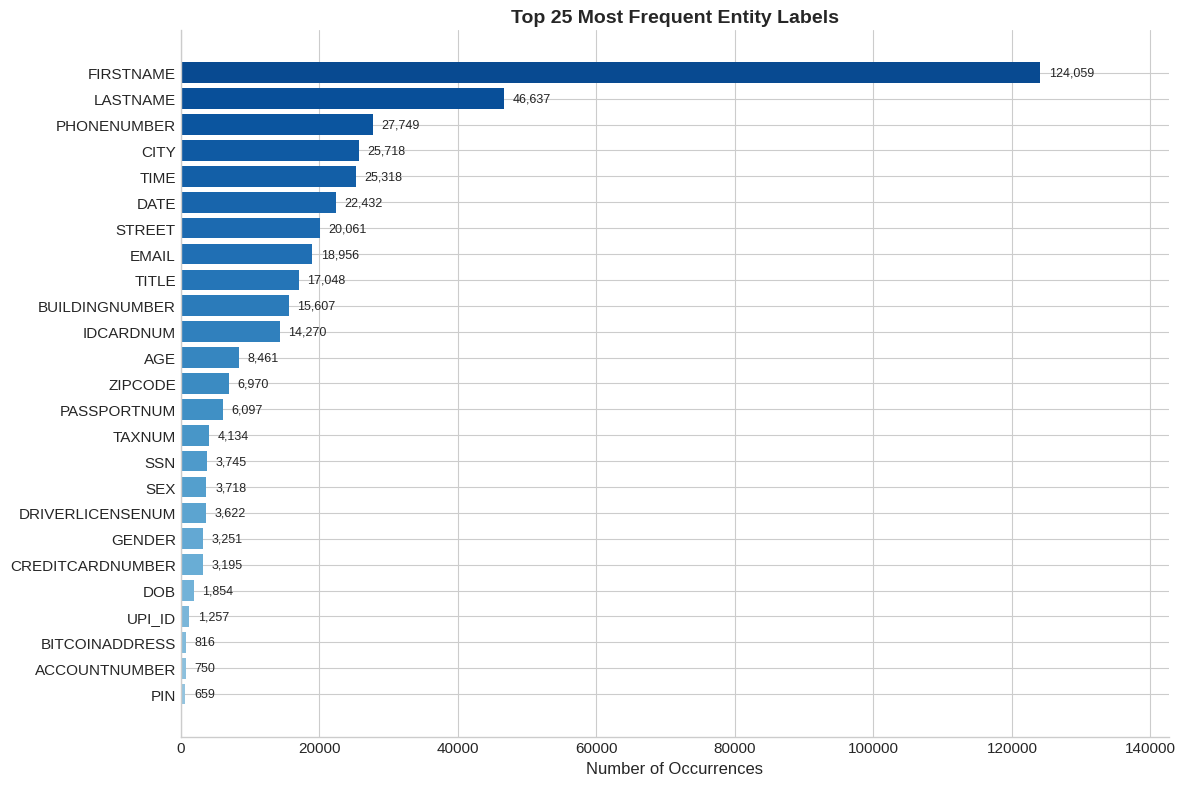

In [8]:
# Visualize top 25 labels
top_n = 25
top_labels = label_counts.most_common(top_n)
labels, counts = zip(*top_labels)

fig, ax = plt.subplots(figsize=(12, 8))

colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
bars = ax.barh(range(top_n), counts, color=colors_gradient)
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Number of Occurrences')
ax.set_title(f'Top {top_n} Most Frequent Entity Labels', fontweight='bold')

# Add count labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + max(counts)*0.01, i, f'{count:,}', va='center', fontsize=9)

ax.set_xlim(0, max(counts) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

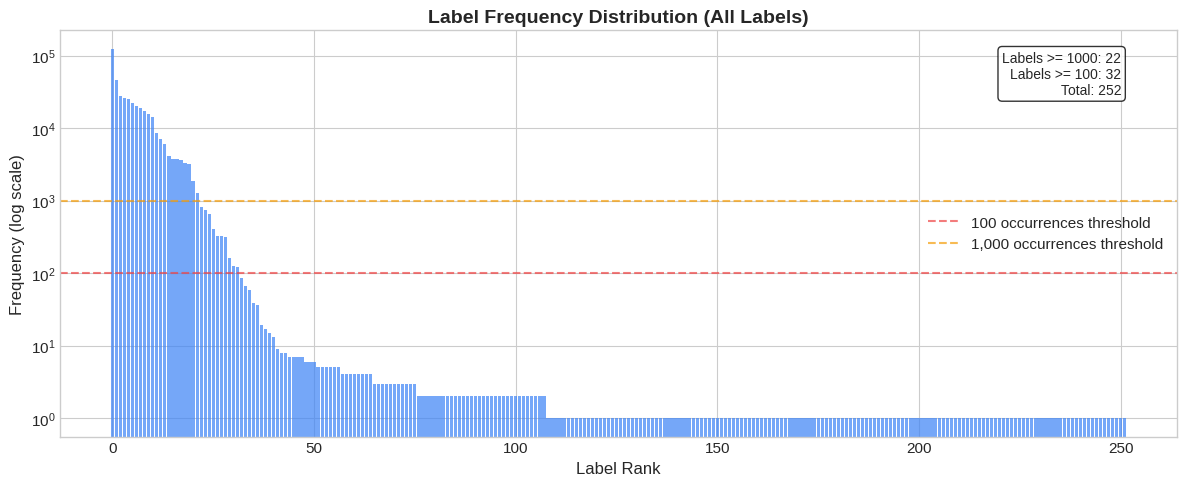

In [9]:
# Label frequency distribution (log scale)
fig, ax = plt.subplots(figsize=(12, 5))

sorted_counts = sorted(label_counts.values(), reverse=True)
ax.bar(range(len(sorted_counts)), sorted_counts, color=COLORS['primary'], alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('Label Rank')
ax.set_ylabel('Frequency (log scale)')
ax.set_title('Label Frequency Distribution (All Labels)', fontweight='bold')

# Add annotations
ax.axhline(y=100, color=COLORS['danger'], linestyle='--', alpha=0.7, label='100 occurrences threshold')
ax.axhline(y=1000, color=COLORS['accent'], linestyle='--', alpha=0.7, label='1,000 occurrences threshold')
ax.legend()

# Stats annotation
labels_above_1000 = sum(1 for c in sorted_counts if c >= 1000)
labels_above_100 = sum(1 for c in sorted_counts if c >= 100)
ax.text(0.95, 0.95, f'Labels >= 1000: {labels_above_1000}\nLabels >= 100: {labels_above_100}\nTotal: {len(sorted_counts)}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_label_frequency_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Synthetic Data Deep Dive

The synthetic data targets six NER failure mode dimensions identified by Singh & Narayanan (2025).

In [10]:
# Filter to synthetic data only
synthetic_df = full_df[full_df['data_source'] == 'synthetic'].copy()

print(f"Synthetic samples: {len(synthetic_df):,}")
print(f"\nFeature Dimensions:")
print("=" * 50)

dimension_counts = synthetic_df['feature_dimension'].value_counts()
for dim, count in dimension_counts.items():
    pct = count / len(synthetic_df) * 100
    print(f"{dim:<20} {count:>6,} ({pct:>5.1f}%)")

Synthetic samples: 6,002

Feature Dimensions:
basic                 1,237 ( 20.6%)
multilingual          1,146 ( 19.1%)
noisy                 1,095 ( 18.2%)
contextual            1,001 ( 16.7%)
evolving                943 ( 15.7%)
adversarial             580 (  9.7%)


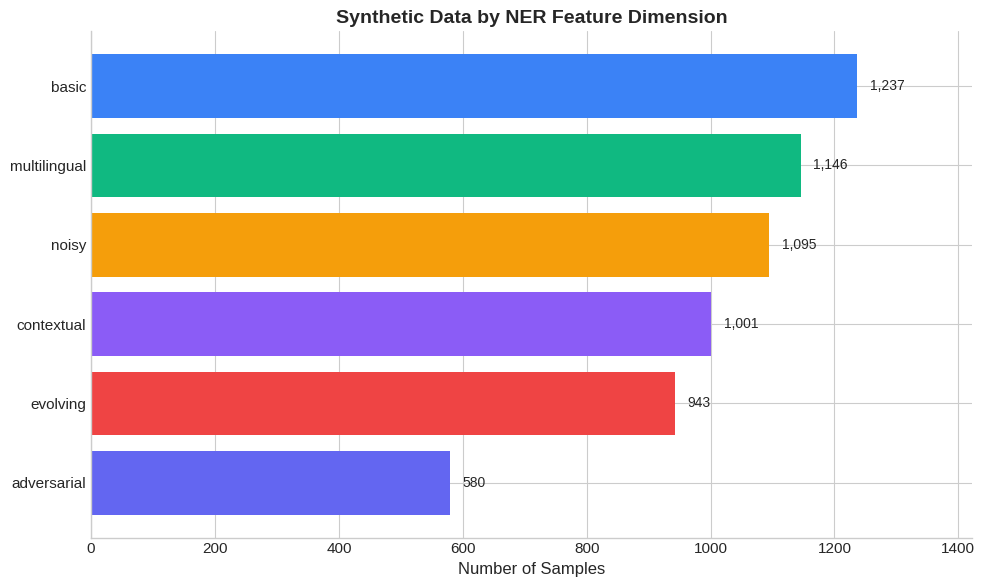


Dimension Descriptions:
------------------------------------------------------------
basic           Standard, well-formatted entities
contextual      Ambiguous entities requiring context
noisy           Typos, informal text, OCR-like errors
evolving        Modern PII: crypto wallets, UPI, TOTP
multilingual    International formats in English text
adversarial     Intentionally deceptive patterns


In [11]:
# Feature dimension descriptions
dimension_descriptions = {
    'basic': 'Standard, well-formatted entities',
    'contextual': 'Ambiguous entities requiring context',
    'noisy': 'Typos, informal text, OCR-like errors',
    'evolving': 'Modern PII: crypto wallets, UPI, TOTP',
    'multilingual': 'International formats in English text',
    'adversarial': 'Intentionally deceptive patterns'
}

# Visualize feature dimensions
fig, ax = plt.subplots(figsize=(10, 6))

dims = list(dimension_counts.index)
counts = list(dimension_counts.values)

colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent'],
          COLORS['purple'], COLORS['danger'], '#6366f1']

bars = ax.barh(dims, counts, color=colors[:len(dims)])
ax.set_xlabel('Number of Samples')
ax.set_title('Synthetic Data by NER Feature Dimension', fontweight='bold')
ax.invert_yaxis()

# Add descriptions as secondary labels
for i, (bar, dim) in enumerate(zip(bars, dims)):
    count = counts[i]
    ax.text(count + 20, i, f'{count:,}', va='center', fontsize=10)

ax.set_xlim(0, max(counts) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_feature_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print descriptions
print("\nDimension Descriptions:")
print("-" * 60)
for dim, desc in dimension_descriptions.items():
    print(f"{dim:<15} {desc}")

In [12]:
# Regional distribution (seed_pii_locale)
locale_counts = synthetic_df['seed_pii_locale'].value_counts()

# Map locale codes to country names
locale_names = {
    'en_IN': 'India',
    'en_US': 'United States',
    'en_GB': 'United Kingdom',
    'en_AU': 'Australia',
    'en_CA': 'Canada',
    'de_DE': 'Germany',
    'fr_FR': 'France',
    'es_ES': 'Spain',
    'it_IT': 'Italy',
    'nl_NL': 'Netherlands'
}

print("Regional PII Format Distribution")
print("=" * 50)
for locale, count in locale_counts.items():
    if pd.notna(locale) and locale:
        country = locale_names.get(locale, locale)
        pct = count / locale_counts.sum() * 100
        print(f"{country:<20} ({locale}) {count:>6,} ({pct:>5.1f}%)")

Regional PII Format Distribution
India                (en_IN)    906 ( 15.1%)
United States        (en_US)    596 (  9.9%)
Netherlands          (nl_NL)    585 (  9.7%)
Canada               (en_CA)    581 (  9.7%)
Spain                (es_ES)    578 (  9.6%)
Italy                (it_IT)    577 (  9.6%)
Australia            (en_AU)    565 (  9.4%)
France               (fr_FR)    564 (  9.4%)
Germany              (de_DE)    527 (  8.8%)
United Kingdom       (en_GB)    523 (  8.7%)


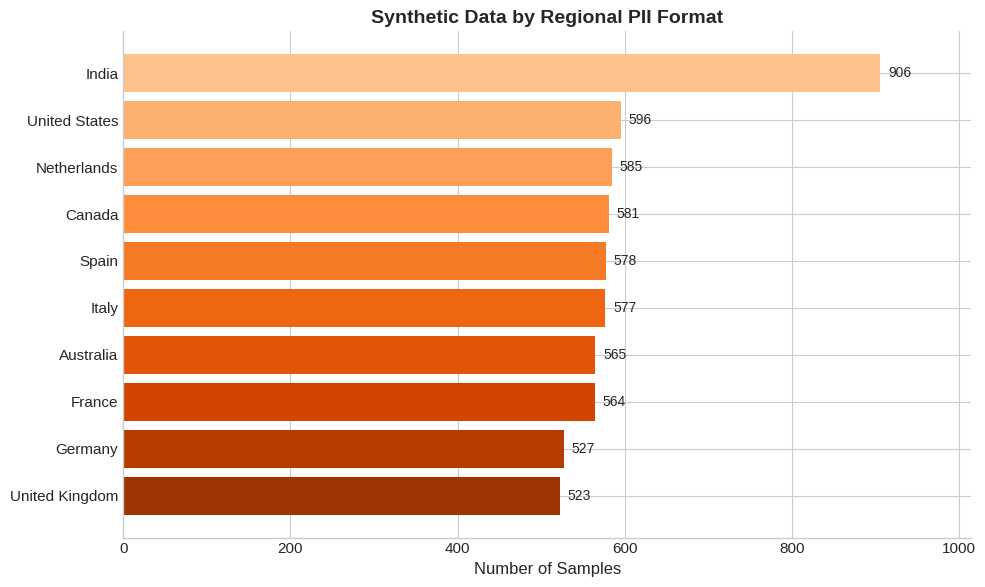

In [13]:
# Visualize locale distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Filter out empty locales and map to country names
locale_data = [(locale_names.get(loc, loc), count)
               for loc, count in locale_counts.items()
               if pd.notna(loc) and loc]
locale_data.sort(key=lambda x: x[1], reverse=True)

countries, counts = zip(*locale_data) if locale_data else ([], [])

colors_gradient = plt.cm.Oranges(np.linspace(0.3, 0.9, len(countries)))
bars = ax.barh(countries, counts, color=colors_gradient)
ax.set_xlabel('Number of Samples')
ax.set_title('Synthetic Data by Regional PII Format', fontweight='bold')
ax.invert_yaxis()

for bar, count in zip(bars, counts):
    ax.text(count + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)

ax.set_xlim(0, max(counts) * 1.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_locale_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Seed PII type distribution
pii_type_counts = synthetic_df['seed_pii_type'].value_counts()

print("Seed PII Type Distribution (Singh & Narayanan Categories)")
print("=" * 60)
for pii_type, count in pii_type_counts.items():
    if pd.notna(pii_type) and pii_type:
        pct = count / pii_type_counts.sum() * 100
        print(f"{pii_type:<35} {count:>6,} ({pct:>5.1f}%)")

Seed PII Type Distribution (Singh & Narayanan Categories)
PHONE                                  424 (  7.1%)
POSTAL_CODE                            420 (  7.0%)
DRIVER_LICENSE                         401 (  6.7%)
NAME                                   396 (  6.6%)
EMAIL                                  390 (  6.5%)
PASSPORT_NUMBER                        390 (  6.5%)
BANK_ACCOUNT                           388 (  6.5%)
VEHICLE_REGISTRATION                   382 (  6.4%)
CREDIT_CARD                            381 (  6.3%)
NATIONAL_IDENTITY_SSN_AADHAR           368 (  6.1%)
BANK_UPI_ID                            361 (  6.0%)
INSURANCE_NUMBER                       360 (  6.0%)
OTHER_NATIONAL_IDENTITY                350 (  5.8%)
DATE_OF_BIRTH                          340 (  5.7%)
TAX_IDENTIFICATION                     328 (  5.5%)
NAMES_OF_PLACES_OR_NOUNS               323 (  5.4%)


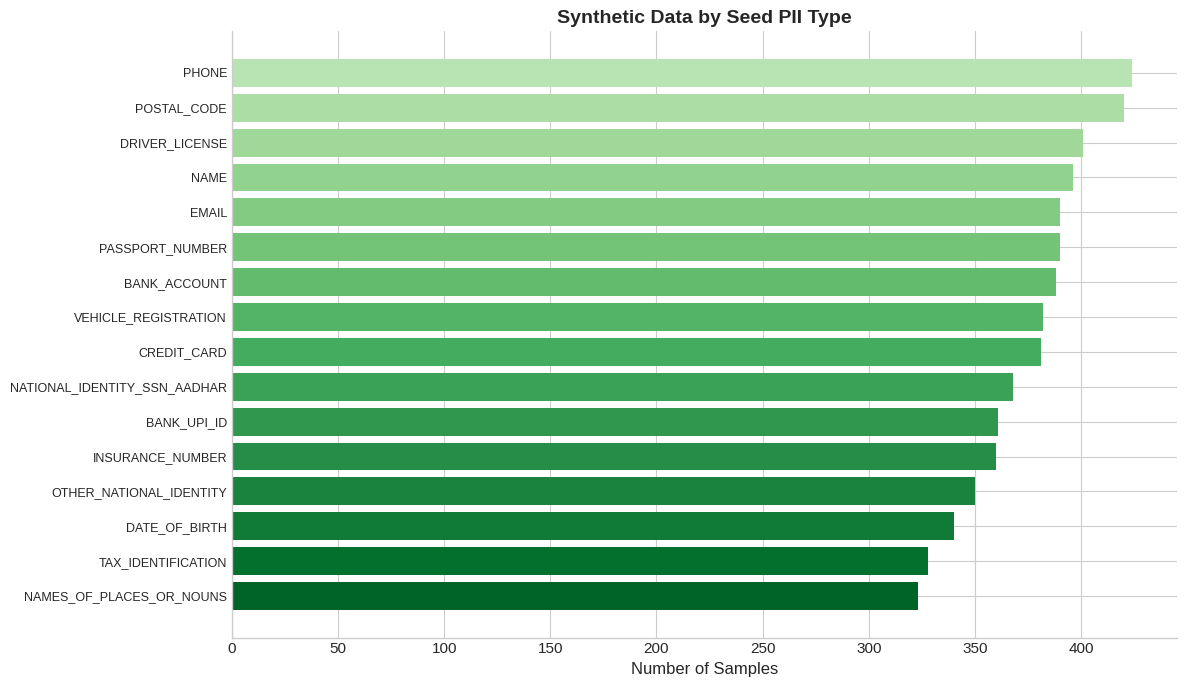

In [15]:
# Visualize seed PII types
fig, ax = plt.subplots(figsize=(12, 7))

pii_data = [(pii, count) for pii, count in pii_type_counts.items()
            if pd.notna(pii) and pii]
pii_data.sort(key=lambda x: x[1], reverse=True)

pii_types, counts = zip(*pii_data) if pii_data else ([], [])

colors_gradient = plt.cm.Greens(np.linspace(0.3, 0.9, len(pii_types)))
bars = ax.barh(range(len(pii_types)), counts, color=colors_gradient)
ax.set_yticks(range(len(pii_types)))
ax.set_yticklabels(pii_types, fontsize=9)
ax.set_xlabel('Number of Samples')
ax.set_title('Synthetic Data by Seed PII Type', fontweight='bold')
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_pii_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Text Statistics

In [16]:
# Calculate text statistics
full_df['text_length'] = full_df['source_text'].str.len()
full_df['word_count'] = full_df['source_text'].str.split().str.len()

# Handle numpy arrays for entity count
def safe_len(x):
    if x is None:
        return 0
    if hasattr(x, 'tolist'):
        x = x.tolist()
    return len(x)

full_df['entity_count'] = full_df['privacy_mask'].apply(safe_len)

print("Text Statistics")
print("=" * 60)
print(f"\nText Length (characters):")
print(f"  Mean:   {full_df['text_length'].mean():,.1f}")
print(f"  Median: {full_df['text_length'].median():,.1f}")
print(f"  Min:    {full_df['text_length'].min():,}")
print(f"  Max:    {full_df['text_length'].max():,}")

print(f"\nWord Count:")
print(f"  Mean:   {full_df['word_count'].mean():,.1f}")
print(f"  Median: {full_df['word_count'].median():,.1f}")

print(f"\nEntities per Sample:")
print(f"  Mean:   {full_df['entity_count'].mean():,.2f}")
print(f"  Median: {full_df['entity_count'].median():,.1f}")
print(f"  Max:    {full_df['entity_count'].max():,}")
print(f"  Samples with 0 entities: {(full_df['entity_count'] == 0).sum():,}")

Text Statistics

Text Length (characters):
  Mean:   115.8
  Median: 104.0
  Min:    1
  Max:    1,194

Word Count:
  Mean:   18.1
  Median: 16.0

Entities per Sample:
  Mean:   2.61
  Median: 2.0
  Max:    36
  Samples with 0 entities: 4,485


In [17]:
# Compare statistics by source
print("\nStatistics by Data Source")
print("=" * 60)

stats_by_source = full_df.groupby('data_source').agg({
    'text_length': ['mean', 'median'],
    'word_count': ['mean', 'median'],
    'entity_count': ['mean', 'median', 'sum']
}).round(1)

print(stats_by_source)


Statistics by Data Source
            text_length        word_count        entity_count               
                   mean median       mean median         mean median     sum
data_source                                                                 
ai4privacy        108.3  102.0       17.0   16.0          2.5    2.0  381698
synthetic         303.6  304.0       45.6   46.0          4.5    5.0   27174


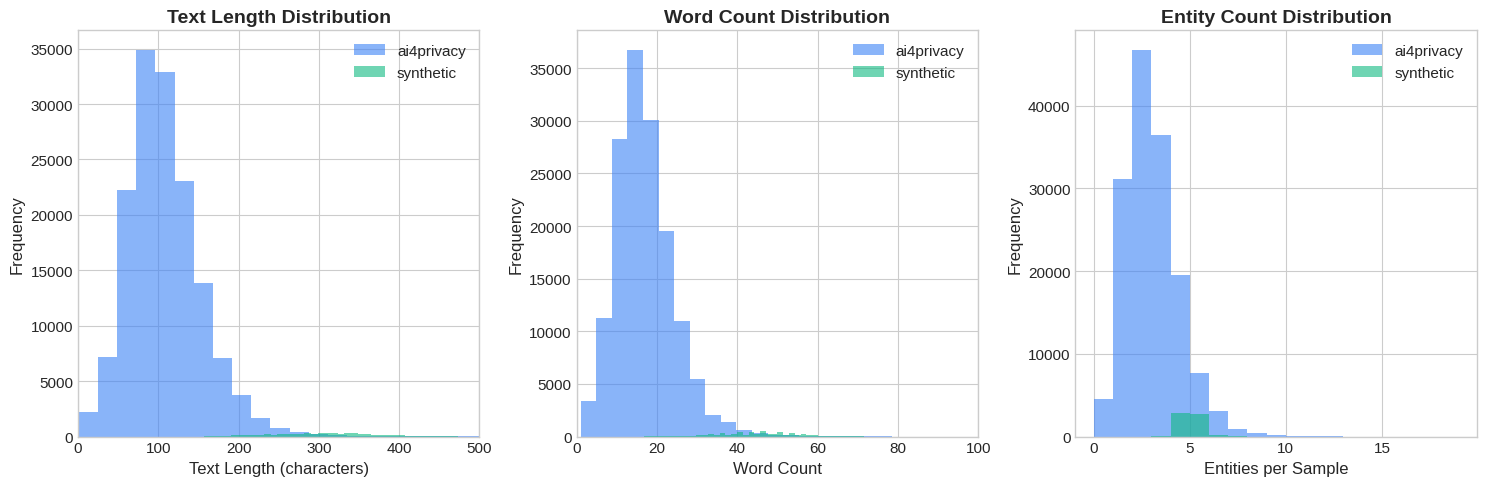

In [18]:
# Visualize text length distribution by source
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Text length distribution
for source, color in [('ai4privacy', COLORS['primary']), ('synthetic', COLORS['secondary'])]:
    data = full_df[full_df['data_source'] == source]['text_length']
    axes[0].hist(data, bins=50, alpha=0.6, label=source, color=color)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Word count distribution
for source, color in [('ai4privacy', COLORS['primary']), ('synthetic', COLORS['secondary'])]:
    data = full_df[full_df['data_source'] == source]['word_count']
    axes[1].hist(data, bins=50, alpha=0.6, label=source, color=color)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 100)

# Entity count distribution
for source, color in [('ai4privacy', COLORS['primary']), ('synthetic', COLORS['secondary'])]:
    data = full_df[full_df['data_source'] == source]['entity_count']
    axes[2].hist(data, bins=range(0, 20), alpha=0.6, label=source, color=color)
axes[2].set_xlabel('Entities per Sample')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Entity Count Distribution', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_text_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Comparison Results

Our DeBERTaV3 + DoRA model was evaluated against four existing PII detection models.

In [19]:
# Model comparison results
results = {
    'Model': [
        'DeBERTa-v3-large + DoRA (Ours)',
        'mDeBERTa-v3-base (ai4privacy 200k)',
        'DistilBERT (ai4privacy 65k)',
        'Piiranha v1',
        'DeBERTa PII (lakshyakh93)'
    ],
    'Precision': [0.898, 0.370, 0.342, 0.600, 0.100],
    'Recall': [0.918, 0.369, 0.368, 0.153, 0.164],
    'F1 Score': [0.908, 0.370, 0.355, 0.244, 0.125],
    'Accuracy': [0.979, 0.842, 0.771, 0.764, 0.723],
    'ROC AUC': [0.9998, 0.974, 0.989, 0.966, 0.988],
    '# Labels': [505, 111, 116, 18, 116]
}

results_df = pd.DataFrame(results)
results_df['Rank'] = range(1, len(results_df) + 1)
results_df = results_df[['Rank', 'Model', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'ROC AUC', '# Labels']]

print("Model Comparison Results")
print("=" * 100)
print(results_df.to_string(index=False))

Model Comparison Results
 Rank                              Model  Precision  Recall  F1 Score  Accuracy  ROC AUC  # Labels
    1     DeBERTa-v3-large + DoRA (Ours)      0.898   0.918     0.908     0.979   0.9998       505
    2 mDeBERTa-v3-base (ai4privacy 200k)      0.370   0.369     0.370     0.842   0.9740       111
    3        DistilBERT (ai4privacy 65k)      0.342   0.368     0.355     0.771   0.9890       116
    4                        Piiranha v1      0.600   0.153     0.244     0.764   0.9660        18
    5          DeBERTa PII (lakshyakh93)      0.100   0.164     0.125     0.723   0.9880       116


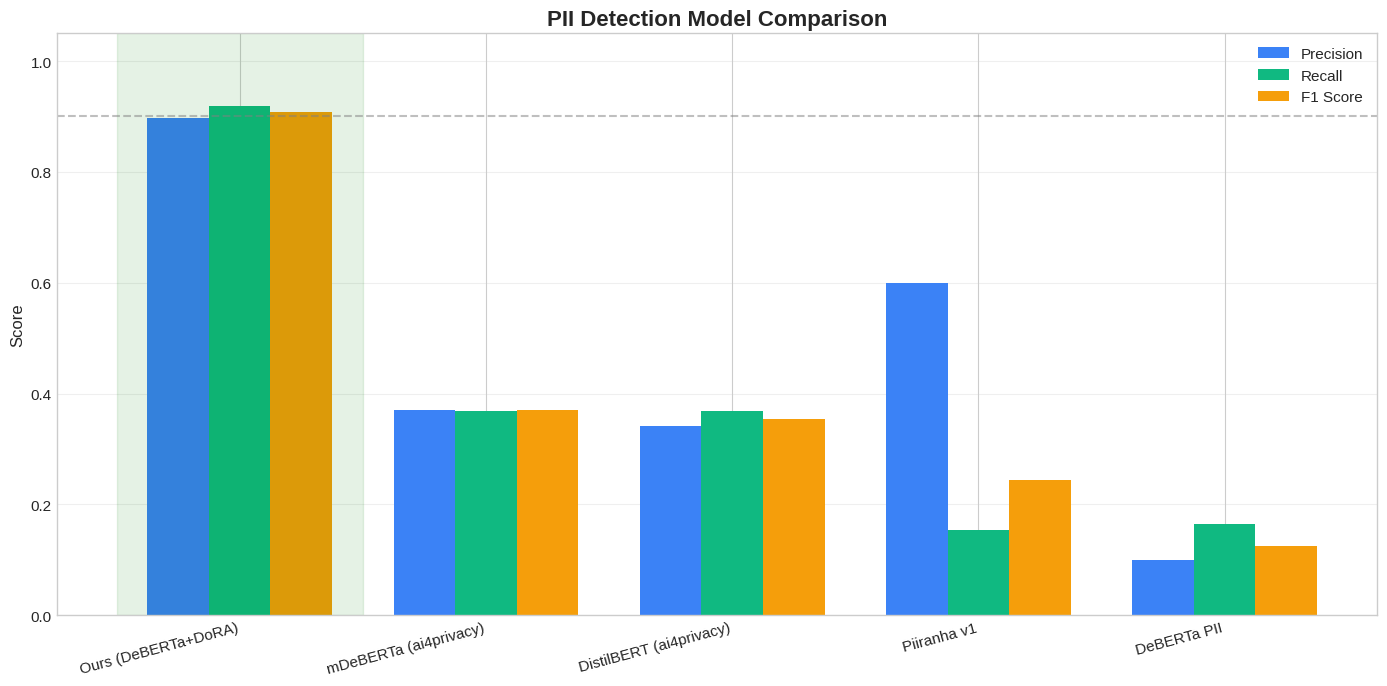


Our F1 Score: 0.908
Best Baseline F1: 0.370
Improvement: 145.4%


In [20]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(14, 7))

models = results_df['Model'].tolist()
# Shorten model names for display
short_names = [
    'Ours (DeBERTa+DoRA)',
    'mDeBERTa (ai4privacy)',
    'DistilBERT (ai4privacy)',
    'Piiranha v1',
    'DeBERTa PII'
]

metrics = ['Precision', 'Recall', 'F1 Score']
x = np.arange(len(short_names))
width = 0.25

colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]

for i, metric in enumerate(metrics):
    values = results_df[metric].tolist()
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=metric, color=colors[i])

ax.set_ylabel('Score')
ax.set_title('PII Detection Model Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=15, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

# Highlight our model
ax.axvspan(-0.5, 0.5, alpha=0.1, color='green')

plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate improvement
our_f1 = results_df.loc[0, 'F1 Score']
best_baseline_f1 = results_df.loc[1:, 'F1 Score'].max()
improvement = (our_f1 - best_baseline_f1) / best_baseline_f1 * 100

print(f"\nOur F1 Score: {our_f1:.3f}")
print(f"Best Baseline F1: {best_baseline_f1:.3f}")
print(f"Improvement: {improvement:.1f}%")

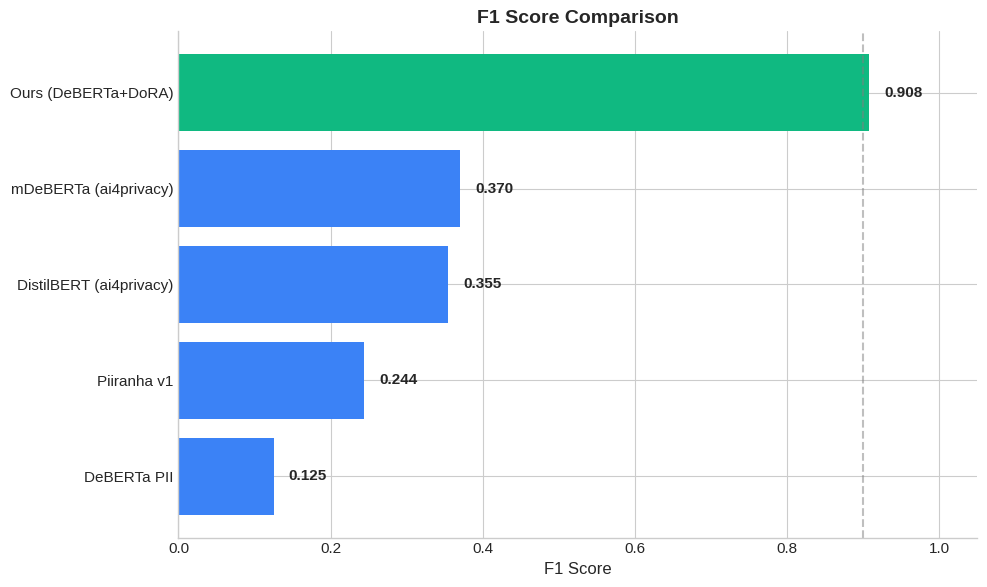

In [21]:
# F1 Score focused comparison
fig, ax = plt.subplots(figsize=(10, 6))

f1_scores = results_df['F1 Score'].tolist()
colors_bars = [COLORS['secondary']] + [COLORS['primary']] * (len(f1_scores) - 1)

bars = ax.barh(short_names[::-1], f1_scores[::-1], color=colors_bars[::-1])
ax.set_xlabel('F1 Score')
ax.set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)

# Add value labels
for bar, score in zip(bars, f1_scores[::-1]):
    ax.text(score + 0.02, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

### Dataset Characteristics
- **Total samples:** 156,695 (125,334 train / 31,361 test)
- **Data sources:** ai4privacy (96.2%) + synthetic (3.8%)
- **Unique labels:** 505 entity types
- **Total entity annotations:** 400,000+

### Synthetic Data
- **6,002 samples** targeting NER failure modes
- **6 feature dimensions:** basic, contextual, noisy, evolving, multilingual, adversarial
- **10 regional formats:** US, UK, India, Canada, Australia, Germany, France, Spain, Italy, Netherlands
- **16 PII types** from Singh & Narayanan (2025) taxonomy

### Model Performance
- **Our model F1:** 0.908
- **Best baseline F1:** 0.370 (mDeBERTa-v3-base)
- **Improvement:** 145% over best baseline, 272% over Piiranha